In [118]:
%load_ext autoreload
%autoreload 2
import tightbinding_system as tbs
import numpy as np
from scipy.linalg import eigh
import matplotlib.pyplot as plt

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [197]:
def create_sites(p: int, q: int, dist_pq: float = 1):
    
    positions = [(_q*p/q, 0) for _q in range(q)] + [(_p, dist_pq) for _p in range(p)]
    return np.array(positions)

def calculate_matrices(sites, a: float, cutoff: float | None = None, plot: bool = False, periodic: bool = False):

    n_sites = len(sites)
    if periodic:
        box_length = np.floor(np.max(sites[:, 0])) - np.floor(np.min(sites[:, 0])) + 1.0
    else:
        box_length = 0.0
    S = np.zeros((n_sites, n_sites), dtype=float)
    T = np.zeros((n_sites, n_sites), dtype=float)
    cutoff_sq = cutoff**2 if cutoff is not None else float('inf')
    for i in range(n_sites):
        for j in range(n_sites):
            s1 = sites[i]
            s2 = sites[j]
            dx = s1[0] - s2[0]
            dy = s1[1] - s2[1]
            if periodic:
                dx = dx - box_length*np.round(dx/box_length)
            dist_sq = dx**2 + dy**2
            if dist_sq > cutoff_sq:
                continue
            exponent = np.exp(-0.5*a*dist_sq)
            S[i, j] = exponent
            T[i, j] = 0.5*a*exponent*(2.0 - a*dist_sq)

    if plot:
        sigma = 1.0/np.sqrt(a)
        margin = 3.0*sigma
        x_min, x_max = sites[:, 0].min() - margin, sites[:, 0].max() + margin
        y_min, y_max = sites[:, 1].min() - margin, sites[:, 1].max() + margin
        
        res_x = 200
        res_y = int(res_x*(y_max - y_min)/(x_max - x_min))
        X, Y = np.meshgrid(np.linspace(x_min, x_max, res_x), np.linspace(y_min, y_max, res_y))
        Z = np.zeros_like(X)
        shift_list = [-box_length, 0, box_length] if periodic else [0]
        for site in sites:
            for shift in shift_list:
                d2 = (X - (site[0] + shift))**2 + (Y - site[1])**2
                Z += np.exp(-0.5 * a * d2)
        plt.figure(figsize=(10, 4))
        plt.contourf(X, Y, Z, levels=50, cmap='Greys')
        plt.scatter(sites[:, 0], sites[:, 1], s=10, c='red', alpha=0.7)
        plt.axis('equal')
        plt.axis('off')
        plt.tight_layout()
        plt.show()

    return S, T

def plot_psi(positions, wavefunctions, a, state_idx=0):

    coeffs = wavefunctions[:, state_idx]
    margin = 2.0
    x_min, x_max = positions[:, 0].min() - margin, positions[:, 0].max() + margin
    y_min, y_max = positions[:, 1].min() - margin, positions[:, 1].max() + margin
    X, Y = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 80))
    Psi = np.zeros_like(X)
    for k, site in enumerate(positions):
        d2 = (X - site[0])**2 + (Y - site[1])**2
        phi = np.sqrt(2*a/np.pi)*np.exp(-a*d2)
        Psi += coeffs[k] * phi
    plt.figure(figsize=(10, 4))
    plt.axis('off')
    plt.axis('equal')
    plt.contourf(X, Y, Psi**2, levels=30, cmap='Greys')
    plt.title(f"$|\Psi|^2$")
    plt.show()
    
from scipy.linalg import eigvals
from scipy.linalg import eig


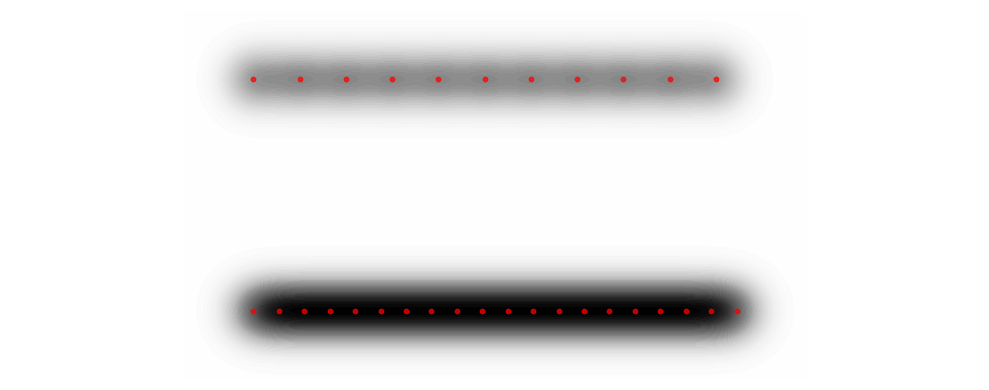

In [223]:
positions = create_sites(p=11, q=20, dist_pq=5)
S, T = calculate_matrices(positions, 4, cutoff=None, plot=True, periodic=False)

In [213]:
a = 4
Energies = []
ipr_list = []
ps = []
for p in range(180, 231, 2):
    positions = create_sites(p=p, q=201, dist_pq=0.01)
    S, T = calculate_matrices(positions, a, cutoff=None, plot=False, periodic=True)
    try:
        energies, vecs = eig(T, S)#type:ignore
    except Exception:
        continue
    energies = np.real(energies)
    idx = np.argsort(energies)
    energies = energies[idx]
    vecs = vecs[:, idx]
    norms = np.linalg.norm(vecs, axis=0)
    vecs_norm = vecs/norms[None, :]
    psi_sq = np.abs(vecs_norm)**2
    ipr = np.sum(psi_sq**2, axis=0)

    Energies.extend(energies)
    ipr_list.extend(ipr)
    ps.extend([p]*len(energies))

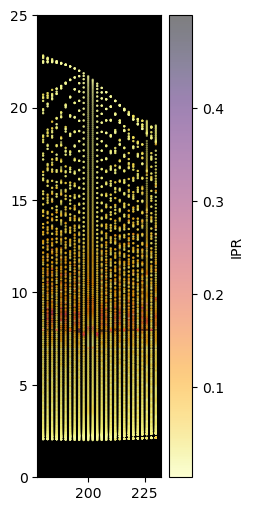

In [214]:
fig, ax = plt.subplots(1,1,figsize=(2, 6))
sc = plt.scatter(ps, Energies, c=ipr_list, cmap='inferno_r', s=0.4, alpha=0.5)
fig.colorbar(sc, label='IPR')
ax.set_facecolor('k')
plt.ylim(0, 25)
plt.show()

In [175]:
a = 4
Energies = []
ipr_list = []
dists = []
for dist in np.linspace(0, 0.04, 20):
    q = 190
    positions = create_sites(p=201, q=q, dist_pq=dist)
    S, T = calculate_matrices(positions, a, cutoff=None, plot=False, periodic=True)
    try:
        energies, vecs = eig(T, S)#type:ignore
    except Exception:
        continue
    energies = np.real(energies)
    idx = np.argsort(energies)
    energies = energies[idx]
    vecs = vecs[:, idx]
    norms = np.linalg.norm(vecs, axis=0)
    vecs_norm = vecs / norms[None, :]
    psi_sq = np.abs(vecs_norm)**2
    ipr = np.sum(psi_sq**2, axis=0)

    Energies.extend(energies)
    ipr_list.extend(ipr)
    dists.extend([dist]*len(energies))

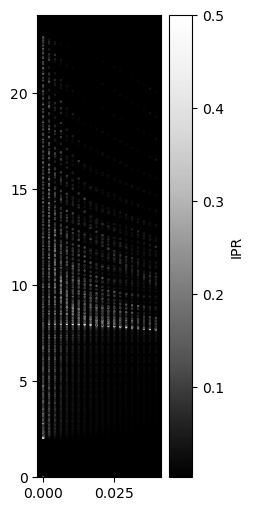

In [176]:
fig, ax = plt.subplots(1,1,figsize=(2, 6))
sc = plt.scatter(dists, Energies, c=ipr_list, cmap='Greys_r', s=0.4, alpha=1)
fig.colorbar(sc, label='IPR')
ax.set_facecolor('k')
plt.ylim(0, None)
plt.show()